# RSETO-IPA simulation-number and lambda sensitivity

This notebook discovers every formal `exp5` sensitivity result, keeps all dimensions and seeds, and compares RSETO-IPA with GenDFL and QFlow on Metric 1 and Metric 2.

In [5]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "legend.title_fontsize": 14,
})


In [ ]:
RESULTS_ROOT = Path("analysis_outputs")
RESULT_PATTERN = re.compile(
    r"^spline_sensitivity_exp5_dim(?P<dim>\d+)_seed(?P<seed>\d+)$"
)

frames = []
source_files = []
for experiment_dir in sorted(RESULTS_ROOT.glob("spline_sensitivity_exp5_dim*_seed*")):
    match = RESULT_PATTERN.match(experiment_dir.name)
    if match is None:
        continue
    dim = int(match.group("dim"))
    seed = int(match.group("seed"))
    for sweep in ("simulation_num", "lambda"):
        detail_path = experiment_dir / sweep / "detail.csv"
        if not detail_path.exists():
            continue
        frame = pd.read_csv(detail_path)
        frame["dim"] = dim
        frame["seed"] = seed
        frame["sweep"] = sweep
        frame["experiment_dir"] = str(experiment_dir)
        frames.append(frame)
        source_files.append(detail_path)

if not frames:
    raise FileNotFoundError(
        "No formal sensitivity results matched "
        "analysis_outputs/spline_sensitivity_exp5_dim*_seed*/{simulation_num,lambda}/detail.csv"
    )

all_results = pd.concat(farmes, ignore_index=True)
all_results["model"] = np.select(
    [
        all_results["method"].eq("gendfl_spline"),
        all_results["method"].eq("spline_qfr"),
        all_results["method"].str.startswith("rseto_ipa"),
    ],
    ["GenDFL", "QFlow", "RSETO-IPA"],
    default=all_results["method"],
)
all_results = all_results.sort_values(
    ["sweep", "dim", "seed", "model", "sweep_value"],
    na_position="first",
).reset_index(drop=True)

print(f"Loaded {len(all_results)} rows from {len(source_files)} result files.")
print(f"Dimensions: {sorted(all_results['dim'].unique().tolist())}")
print(f"Seeds: {sorted(all_results['seed'].unique().tolist())}")
display(
    all_results[[
        "sweep", "dim", "seed", "model", "method",
        "sweep_value", "metric1", "metric2", "epochs_ran",
    ]]
)


Loaded 14 rows from 2 result files.
Dimensions: [4]
Seeds: [82]


,sweep,dim,seed,model,method,sweep_value,metric1,metric2,epochs_ran
0,lambda,4,82,GenDFL,gendfl_spline,NaN,97.559631,132.390564,29
1,lambda,4,82,QFlow,spline_qfr,NaN,97.493912,128.541061,26
2,lambda,4,82,RSETO-IPA,rseto_ipa_lambda0.1,0.1,96.916962,115.709198,26
3,lambda,4,82,RSETO-IPA,rseto_ipa_lambda0.3,0.3,97.501595,118.340683,22
4,lambda,4,82,RSETO-IPA,rseto_ipa_lambda0.5,0.5,97.251823,128.299026,29
5,lambda,4,82,RSETO-IPA,rseto_ipa_lambda0.7,0.7,96.904488,126.681244,38
6,lambda,4,82,RSETO-IPA,rseto_ipa_lambda0.9,0.9,96.889702,134.981537,56
7,simulation_num,4,82,GenDFL,gendfl_spline,NaN,97.559631,132.390564,29
8,simulation_num,4,82,QFlow,spline_qfr,NaN,97.493912,128.541061,26
9,simulation_num,4,82,RSETO-IPA,rseto_ipa_R1,1.0,97.220535,122.474892,54


In [14]:
all_results

,method,sweep_type,sweep_value,metric1,metric2,replications,samples_per_replication,fidelity_weight,smoothing_mu,epochs_ran,...,baseline_reused,training_reused,parameter_count,prediction_path,checkpoint_path,dim,seed,sweep,experiment_dir,model
0,gendfl_spline,lambda,NaN,97.559631,132.390564,NaN,NaN,NaN,NaN,29,...,True,True,30140,analysis_outputs/spline_sensitivity_exp5_dim4_...,analysis_outputs/spline_sensitivity_exp5_dim4_...,4,82,lambda,analysis_outputs/spline_sensitivity_exp5_dim4_...,GenDFL
1,spline_qfr,lambda,NaN,97.493912,128.541061,NaN,NaN,NaN,NaN,26,...,True,True,30140,analysis_outputs/spline_sensitivity_exp5_dim4_...,analysis_outputs/spline_sensitivity_exp5_dim4_...,4,82,lambda,analysis_outputs/spline_sensitivity_exp5_dim4_...,QFlow
2,rseto_ipa_lambda0.1,lambda,0.1,96.916962,115.709198,5.0,32.0,0.1,0.05,26,...,False,False,30140,analysis_outputs/spline_sensitivity_exp5_dim4_...,analysis_outputs/spline_sensitivity_exp5_dim4_...,4,82,lambda,analysis_outputs/spline_sensitivity_exp5_dim4_...,RSETO-IPA
3,rseto_ipa_lambda0.3,lambda,0.3,97.501595,118.340683,5.0,32.0,0.3,0.05,22,...,False,False,30140,analysis_outputs/spline_sensitivity_exp5_dim4_...,analysis_outputs/spline_sensitivity_exp5_dim4_...,4,82,lambda,analysis_outputs/spline_sensitivity_exp5_dim4_...,RSETO-IPA
4,rseto_ipa_lambda0.5,lambda,0.5,97.251823,128.299026,5.0,32.0,0.5,0.05,29,...,False,True,30140,analysis_outputs/spline_sensitivity_exp5_dim4_...,analysis_outputs/spline_sensitivity_exp5_dim4_...,4,82,lambda,analysis_outputs/spline_sensitivity_exp5_dim4_...,RSETO-IPA
5,rseto_ipa_lambda0.7,lambda,0.7,96.904488,126.681244,5.0,32.0,0.7,0.05,38,...,False,False,30140,analysis_outputs/spline_sensitivity_exp5_dim4_...,analysis_outputs/spline_sensitivity_exp5_dim4_...,4,82,lambda,analysis_outputs/spline_sensitivity_exp5_dim4_...,RSETO-IPA
6,rseto_ipa_lambda0.9,lambda,0.9,96.889702,134.981537,5.0,32.0,0.9,0.05,56,...,False,False,30140,analysis_outputs/spline_sensitivity_exp5_dim4_...,analysis_outputs/spline_sensitivity_exp5_dim4_...,4,82,lambda,analysis_outputs/spline_sensitivity_exp5_dim4_...,RSETO-IPA
7,gendfl_spline,simulation_num,NaN,97.559631,132.390564,NaN,NaN,NaN,NaN,29,...,False,False,30140,analysis_outputs/spline_sensitivity_exp5_dim4_...,analysis_outputs/spline_sensitivity_exp5_dim4_...,4,82,simulation_num,analysis_outputs/spline_sensitivity_exp5_dim4_...,GenDFL
8,spline_qfr,simulation_num,NaN,97.493912,128.541061,NaN,NaN,NaN,NaN,26,...,False,False,30140,analysis_outputs/spline_sensitivity_exp5_dim4_...,analysis_outputs/spline_sensitivity_exp5_dim4_...,4,82,simulation_num,analysis_outputs/spline_sensitivity_exp5_dim4_...,QFlow
9,rseto_ipa_R1,simulation_num,1.0,97.220535,122.474892,1.0,32.0,0.5,0.05,54,...,False,False,30140,analysis_outputs/spline_sensitivity_exp5_dim4_...,analysis_outputs/spline_sensitivity_exp5_dim4_...,4,82,simulation_num,analysis_outputs/spline_sensitivity_exp5_dim4_...,RSETO-IPA


In [7]:
numeric_summary = (
    all_results.groupby(
        ["sweep", "dim", "model", "sweep_value"],
        dropna=False,
        as_index=False,
    )
    .agg(
        metric1_mean=("metric1", "mean"),
        metric1_std=("metric1", "std"),
        metric2_mean=("metric2", "mean"),
        metric2_std=("metric2", "std"),
        num_seeds=("seed", "nunique"),
    )
    .sort_values(["sweep", "dim", "model", "sweep_value"], na_position="first")
    .reset_index(drop=True)
)
display(numeric_summary)


,sweep,dim,model,sweep_value,metric1_mean,metric1_std,metric2_mean,metric2_std,num_seeds
0,lambda,4,GenDFL,NaN,97.559631,NaN,132.390564,NaN,1
1,lambda,4,QFlow,NaN,97.493912,NaN,128.541061,NaN,1
2,lambda,4,RSETO-IPA,0.1,96.916962,NaN,115.709198,NaN,1
3,lambda,4,RSETO-IPA,0.3,97.501595,NaN,118.340683,NaN,1
4,lambda,4,RSETO-IPA,0.5,97.251823,NaN,128.299026,NaN,1
5,lambda,4,RSETO-IPA,0.7,96.904488,NaN,126.681244,NaN,1
6,lambda,4,RSETO-IPA,0.9,96.889702,NaN,134.981537,NaN,1
7,simulation_num,4,GenDFL,NaN,97.559631,NaN,132.390564,NaN,1
8,simulation_num,4,QFlow,NaN,97.493912,NaN,128.541061,NaN,1
9,simulation_num,4,RSETO-IPA,1.0,97.220535,NaN,122.474892,NaN,1


In [8]:
PLOT_DIR = RESULTS_ROOT / "spline_sensitivity_analysis"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_STYLES = {
    "GenDFL": {"linestyle": (0, (7, 3)), "linewidth": 2.0},
    "QFlow": {"linestyle": (0, (4, 2)), "linewidth": 2.0},
}

def plot_sensitivity(results, sweep, x_label, output_stem):
    data = results.loc[results["sweep"].eq(sweep)].copy()
    if data.empty:
        raise ValueError(f"No results found for sweep={sweep!r}.")

    dims = sorted(data["dim"].unique().tolist())
    palette = sns.color_palette("Set2", n_colors=len(dims))
    color_by_dim = dict(zip(dims, palette))
    fig, axes = plt.subplots(
        nrows=len(dims),
        ncols=2,
        figsize=(12, 5 * len(dims)),
        squeeze=False,
        sharex=False,
    )

    legend_handles = None
    legend_labels = None
    for row, dim in enumerate(dims):
        dim_data = data.loc[data["dim"].eq(dim)]
        sensitivity = dim_data.loc[dim_data["model"].eq("RSETO-IPA")]
        x_values = sorted(sensitivity["sweep_value"].dropna().unique().tolist())

        for column, metric in enumerate(("metric1", "metric2")):
            axis = axes[row, column]
            grouped = (
                sensitivity.groupby("sweep_value")[metric]
                .agg(["mean", "std", "count"])
                .reset_index()
                .sort_values("sweep_value")
            )
            axis.plot(
                grouped["sweep_value"],
                grouped["mean"],
                color=color_by_dim[dim],
                marker="o",
                markersize=7,
                linewidth=2.5,
                label="RSETO-IPA",
                zorder=3,
            )
            valid_std = grouped["std"].notna() & grouped["std"].gt(0)
            if valid_std.any():
                axis.fill_between(
                    grouped.loc[valid_std, "sweep_value"],
                    grouped.loc[valid_std, "mean"] - grouped.loc[valid_std, "std"],
                    grouped.loc[valid_std, "mean"] + grouped.loc[valid_std, "std"],
                    color=color_by_dim[dim],
                    alpha=0.18,
                    linewidth=0,
                )

            for baseline, style in BASELINE_STYLES.items():
                baseline_values = dim_data.loc[
                    dim_data["model"].eq(baseline), metric
                ].dropna()
                if baseline_values.empty:
                    continue
                axis.axhline(
                    baseline_values.mean(),
                    color="black",
                    linestyle=style["linestyle"],
                    linewidth=style["linewidth"],
                    label=baseline,
                    zorder=2,
                )

            axis.set_title(f"Dim {dim} - {metric.replace('metric', 'Metric ')}")
            axis.set_xlabel(x_label, fontweight="bold")
            axis.set_ylabel("Average cost", fontweight="bold")
            axis.set_xticks(x_values)
            axis.grid(True, which="both", linestyle="--", alpha=0.5)
            sns.despine(ax=axis)
            if legend_handles is None:
                legend_handles, legend_labels = axis.get_legend_handles_labels()

    unique_legend = dict(zip(legend_labels, legend_handles))
    fig.legend(
        unique_legend.values(),
        unique_legend.keys(),
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        frameon=True,
        borderpad=0.8,
        labelspacing=0.8,
    )
    fig.tight_layout(rect=(0, 0, 0.88, 1))

    png_path = PLOT_DIR / f"{output_stem}.png"
    pdf_path = PLOT_DIR / f"{output_stem}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    return png_path, pdf_path


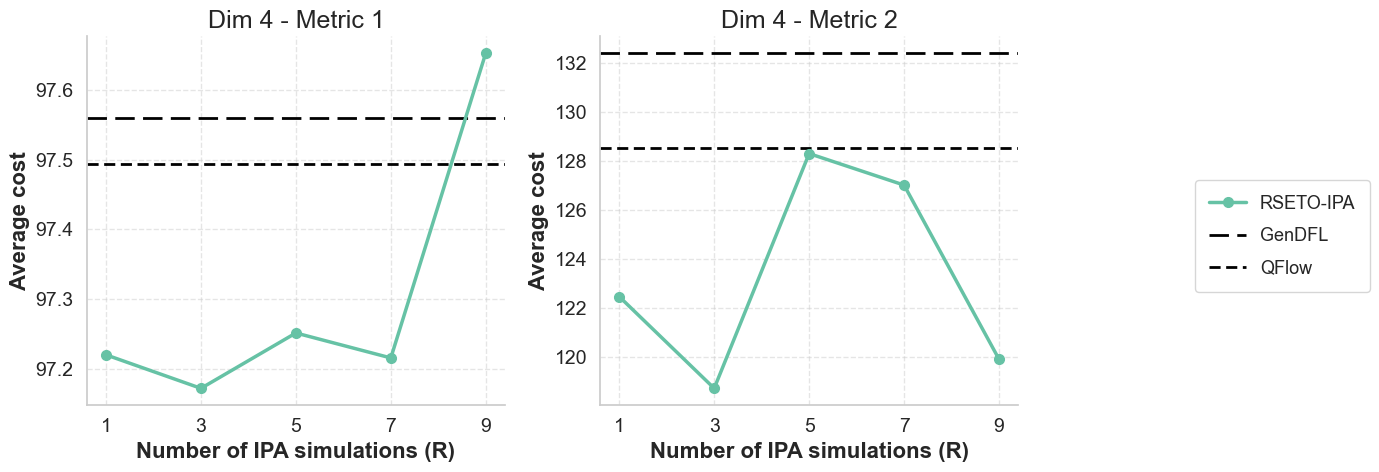

Saved:
analysis_outputs/spline_sensitivity_analysis/simulation_num_metric1_metric2_by_dim.png
analysis_outputs/spline_sensitivity_analysis/simulation_num_metric1_metric2_by_dim.pdf


In [9]:
simulation_paths = plot_sensitivity(
    all_results,
    sweep="simulation_num",
    x_label="Number of IPA simulations (R)",
    output_stem="simulation_num_metric1_metric2_by_dim",
)
print("Saved:", *simulation_paths, sep="\n")


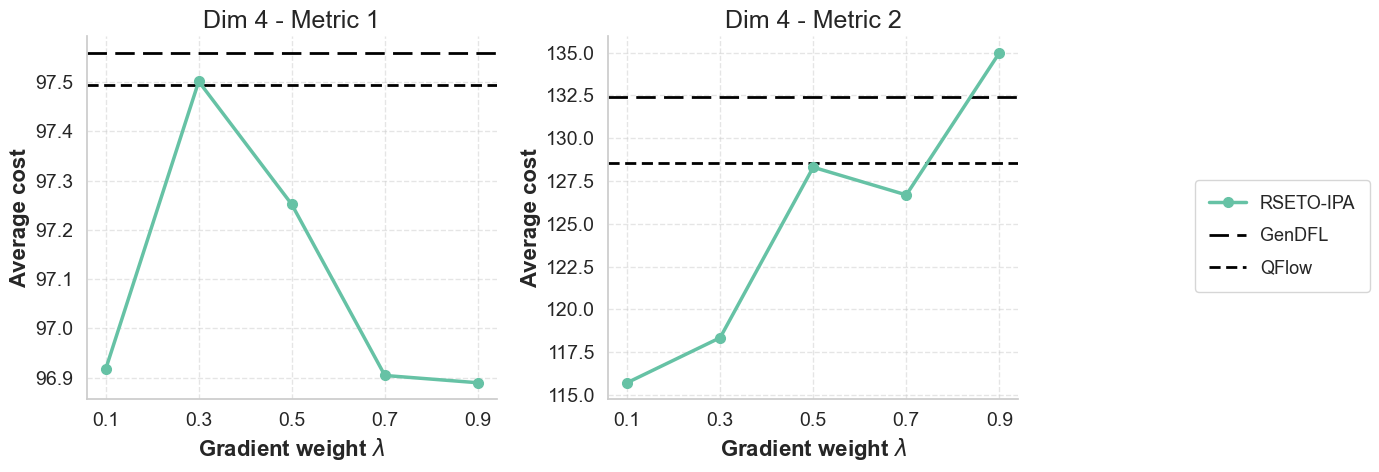

Saved:
analysis_outputs/spline_sensitivity_analysis/lambda_metric1_metric2_by_dim.png
analysis_outputs/spline_sensitivity_analysis/lambda_metric1_metric2_by_dim.pdf


In [10]:
lambda_paths = plot_sensitivity(
    all_results,
    sweep="lambda",
    x_label=r"Gradient weight $\lambda$",
    output_stem="lambda_metric1_metric2_by_dim",
)
print("Saved:", *lambda_paths, sep="\n")


## Existing ETO and benchmark results

The four summary workbooks generated by `read_data.ipynb` are loaded from the extracted `result` directory. `NETE` is reported as `Benchmark`, and the best non-EMP method in each row is bolded in the LaTeX output.

In [11]:
LEGACY_RESULT_DIR = Path("result")
LEGACY_TABLE_FILES = {
    "Exp. 1 - Metric 1": "model_performance_linear.xlsx",
    "Exp. 1 - Metric 2": "model_performance_linear_series.xlsx",
    "Exp. 5 - Metric 1": "model_performance_peak.xlsx",
    "Exp. 5 - Metric 2": "model_performance_peak_series.xlsx",
}

legacy_tables = {}
for table_name, filename in LEGACY_TABLE_FILES.items():
    source_path = LEGACY_RESULT_DIR / filename
    if not source_path.exists():
        raise FileNotFoundError(source_path)
    table = pd.read_excel(source_path).rename(
        columns={"NETE": "Benchmark", "PRE_IPA": "PRE-IPA", "PRE_GLR": "PRE-GLR"}
    )
    legacy_tables[table_name] = table
    print(f"{table_name}: {source_path} ({table.shape[0]} rows, {table.shape[1]} columns)")
    display(table)


Exp. 1 - Metric 1: result/model_performance_linear.xlsx (5 rows, 15 columns)


,Dim,ETO,SETO-IPA,SETO-GLR,LR-IPA,LR-GLR,BSGLR-LR,GEN-ETE-IPA,GEN-ETE-GLR,PRE-IPA,PRE-GLR,Benchmark,LGB,ERM,EMP
0,4,196.789413,196.142502,196.545898,195.144699,195.189789,196.949158,193.870575,200.470261,194.756241,199.228302,193.339905,433.511556,433.543464,484.473501
1,9,429.560455,430.657806,429.851471,423.675964,429.536926,429.091003,420.864197,439.827484,424.723816,428.769470,421.600281,724.758832,720.799716,491.927825
2,14,450.216644,451.305267,449.733490,448.479156,450.983582,453.563568,445.614166,458.078613,445.753662,452.725250,445.418121,531.155979,530.489780,455.933027
3,19,452.022369,451.272522,451.385406,446.032623,451.334045,452.123962,443.455475,459.997559,446.093842,452.178772,444.104004,1111.880458,1111.668271,438.804450
4,24,533.667969,534.219421,533.525696,533.312683,533.991333,534.338623,534.778931,533.966125,534.508484,534.067444,533.407349,835.890053,834.129123,493.525854


Exp. 1 - Metric 2: result/model_performance_linear_series.xlsx (5 rows, 15 columns)


,Dim,ETO,SETO-IPA,SETO-GLR,LR-IPA,LR-GLR,BSGLR-LR,GEN-ETE-IPA,GEN-ETE-GLR,PRE-IPA,PRE-GLR,Benchmark,LGB,ERM,EMP
0,4,279.819587,279.044100,279.964786,279.554576,279.147706,281.012133,291.179225,286.600195,281.783009,281.267181,295.164185,430.836970,431.907753,392.501989
1,9,304.131883,304.895565,304.567567,301.285371,304.518007,304.584849,303.539664,309.012162,302.952311,303.602814,304.728302,679.853790,677.233649,358.452203
2,14,471.147407,470.700111,470.243743,469.588043,470.749151,472.895397,480.618795,479.695950,469.265618,472.675842,483.674500,499.370824,499.969867,354.670451
3,19,531.843235,531.727135,531.676820,529.044031,531.843133,532.142646,533.428757,539.850886,530.805807,535.741699,532.153931,1138.581978,1138.829984,340.251913
4,24,645.368946,646.480114,646.305852,644.446681,646.640961,647.555280,671.093653,656.700939,649.159331,649.105591,676.795959,779.388604,778.208757,343.434092


Exp. 5 - Metric 1: result/model_performance_peak.xlsx (5 rows, 15 columns)


,Dim,ETO,SETO-IPA,SETO-GLR,LR-IPA,LR-GLR,BSGLR-LR,GEN-ETE-IPA,GEN-ETE-GLR,PRE-IPA,PRE-GLR,Benchmark,LGB,ERM,EMP
0,4,313.321472,313.946136,312.110291,308.387878,314.069702,314.147034,316.553406,350.683472,354.485443,337.268616,312.101746,402.713781,474.126784,549.269011
1,9,348.991364,340.881104,353.140930,342.967957,349.070709,351.530945,352.313965,376.531067,367.034088,356.301819,352.057312,552.093270,579.448860,498.441946
2,14,340.968567,368.581421,339.677399,356.271545,343.236725,341.883881,372.976135,377.031891,359.899353,352.970337,360.372437,619.614188,659.654886,497.156438
3,19,595.006226,586.640503,586.461060,559.441223,588.099731,590.757446,609.123596,668.283020,685.649780,617.732178,536.933777,777.361944,748.457496,563.129279
4,24,617.748535,627.030640,619.428101,617.462402,618.724426,618.407349,608.338013,635.450439,659.303284,675.638672,642.931458,834.070350,888.839597,581.562356


Exp. 5 - Metric 2: result/model_performance_peak_series.xlsx (5 rows, 15 columns)


,Dim,ETO,SETO-IPA,SETO-GLR,LR-IPA,LR-GLR,BSGLR-LR,GEN-ETE-IPA,GEN-ETE-GLR,PRE-IPA,PRE-GLR,Benchmark,LGB,ERM,EMP
0,4,327.963421,327.046704,327.098666,329.956375,327.748053,329.466095,439.399782,372.790603,378.541002,364.725952,453.028320,448.902021,490.703084,394.206238
1,9,330.780790,326.426891,335.250097,331.526635,333.267683,333.533300,465.339227,362.762729,346.338495,346.122162,487.958313,621.502031,615.443979,360.572011
2,14,375.062035,383.692809,374.530799,386.450402,376.647122,370.891799,546.394386,404.865844,409.640435,385.266418,602.423035,861.380469,872.619310,365.205036
3,19,487.302718,490.702999,484.729166,476.133153,485.821155,490.875569,517.555144,526.940532,534.745177,491.505219,521.926880,966.445187,1049.832623,409.768188
4,24,603.970662,607.983953,609.491090,603.623577,607.203840,605.364683,805.880459,657.143002,667.017256,637.760132,993.721191,931.571272,960.134641,418.060264


In [12]:
LATEX_DIR = LEGACY_RESULT_DIR / "latex_tables"
LATEX_DIR.mkdir(parents=True, exist_ok=True)

LATEX_SPECS = {
    "Exp. 1 - Metric 1": (
        "model_performance_linear.tex",
        "Synthetic Experiment 1: Metric 1",
        "tab:syn_exp1_metric1",
    ),
    "Exp. 1 - Metric 2": (
        "model_performance_linear_series.tex",
        "Synthetic Experiment 1: Metric 2",
        "tab:syn_exp1_metric2",
    ),
    "Exp. 5 - Metric 1": (
        "model_performance_peak.tex",
        "Synthetic Experiment 5: Metric 1",
        "tab:syn_exp5_metric1",
    ),
    "Exp. 5 - Metric 2": (
        "model_performance_peak_series.tex",
        "Synthetic Experiment 5: Metric 2",
        "tab:syn_exp5_metric2",
    ),
}

def dataframe_to_latex(table, caption, label):
    method_columns = [column for column in table.columns if column != "Dim"]
    comparison_columns = [column for column in method_columns if column != "EMP"]
    column_spec = "l" + "r" * len(method_columns)
    lines = [
        r"\begin{table}[t]",
        r"\centering",
        f"\\caption{{{caption}}}",
        f"\\label{{{label}}}",
        r"\resizebox{\textwidth}{!}{%",
        f"\\begin{{tabular}}{{{column_spec}}}",
        r"\toprule",
        " & ".join(table.columns) + r" \\",
        r"\midrule",
    ]
    for _, row in table.iterrows():
        best_column = row[comparison_columns].astype(float).idxmin()
        cells = [str(int(row["Dim"]))]
        for column in method_columns:
            value = float(row[column])
            formatted = f"{value:.2f}"
            if column == best_column:
                formatted = rf"\textbf{{{formatted}}}"
            cells.append(formatted)
        lines.append(" & ".join(cells) + r" \\")
    lines.extend([
        r"\bottomrule",
        r"\end{tabular}%",
        r"}",
        r"\end{table}",
    ])
    return "\n".join(lines)

combined_latex = []
latex_paths = []
for table_name, table in legacy_tables.items():
    filename, caption, label = LATEX_SPECS[table_name]
    latex_code = dataframe_to_latex(table, caption, label)
    output_path = LATEX_DIR / filename
    output_path.write_text(latex_code + "\n", encoding="utf-8")
    latex_paths.append(output_path)
    combined_latex.append(latex_code)
    print(f"\n% {table_name}\n{latex_code}\n")

combined_path = LATEX_DIR / "all_model_performance_tables.tex"
combined_path.write_text("\n\n".join(combined_latex) + "\n", encoding="utf-8")
print("Saved LaTeX files:", *latex_paths, combined_path, sep="\n")



% Exp. 1 - Metric 1
\begin{table}[t]
\centering
\caption{Synthetic Experiment 1: Metric 1}
\label{tab:syn_exp1_metric1}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lrrrrrrrrrrrrrr}
\toprule
Dim & ETO & SETO-IPA & SETO-GLR & LR-IPA & LR-GLR & BSGLR-LR & GEN-ETE-IPA & GEN-ETE-GLR & PRE-IPA & PRE-GLR & Benchmark & LGB & ERM & EMP \\
\midrule
4 & 196.79 & 196.14 & 196.55 & 195.14 & 195.19 & 196.95 & 193.87 & 200.47 & 194.76 & 199.23 & \textbf{193.34} & 433.51 & 433.54 & 484.47 \\
9 & 429.56 & 430.66 & 429.85 & 423.68 & 429.54 & 429.09 & \textbf{420.86} & 439.83 & 424.72 & 428.77 & 421.60 & 724.76 & 720.80 & 491.93 \\
14 & 450.22 & 451.31 & 449.73 & 448.48 & 450.98 & 453.56 & 445.61 & 458.08 & 445.75 & 452.73 & \textbf{445.42} & 531.16 & 530.49 & 455.93 \\
19 & 452.02 & 451.27 & 451.39 & 446.03 & 451.33 & 452.12 & \textbf{443.46} & 460.00 & 446.09 & 452.18 & 444.10 & 1111.88 & 1111.67 & 438.80 \\
24 & 533.67 & 534.22 & 533.53 & \textbf{533.31} & 533.99 & 534.34 & 534.78 & 533.97 & 534.51 &